In [6]:
import gurobipy as gp
import scipy as sp
import numpy as np
import linopy
import matplotlib.pyplot as plt

In [4]:
# Optimize min x^2 + y subject to x - y >= 2
m = gp.Model()
x = m.addVar(name="x")
y = m.addVar(name="y")
m.setObjective(x * x + y, gp.GRB.MINIMIZE)
m.addConstr(x - y >= 2, "c0")
m.optimize()
print(f"Optimal objective: {m.objVal}")
print(f"Optimal x: {x.x}, Optimal y: {y.x}")


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 2 columns and 2 nonzeros (Min)
Model fingerprint: 0xbda60afd
Model has 1 linear objective coefficients
Model has 1 quadratic objective term
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+00, 2e+00]
Presolve removed 1 rows and 2 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Barrier solved model in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective 4.00000000e+00
Optimal objective: 4.0
Optimal x: 2.0, Optimal y: 0.0


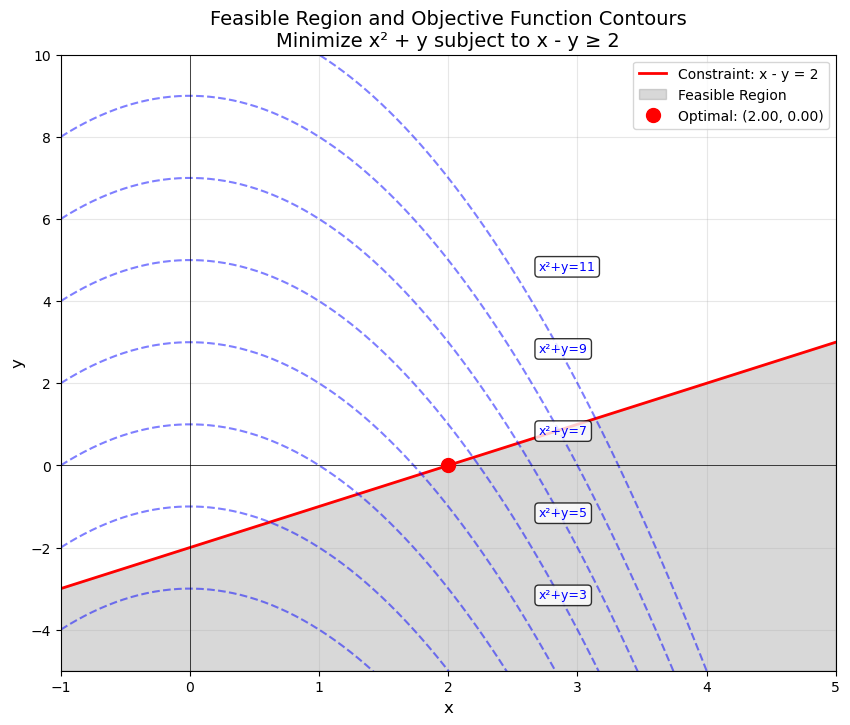

In [7]:
# Draw the feasible region and the objective function
plt.figure(figsize=(10, 8))
x_vals = np.linspace(-1, 5, 100)
y_constraint = x_vals - 2  # From the constraint x - y >= 2, so y <= x - 2

# Plot constraint boundary
plt.plot(x_vals, y_constraint, label='Constraint: x - y = 2', color='red', linewidth=2)

# Shade feasible region (y <= x - 2)
plt.fill_between(x_vals, y_constraint, -5, color='gray', alpha=0.3, label='Feasible Region')

# Objective function contours: x^2 + y = c, so y = c - x^2
contour_values = [-3, -1, 1, 3, 5, 7, 9, 11]
for c in contour_values:
    y_obj = c - x_vals**2
    plt.plot(x_vals, y_obj, linestyle='--', color='blue', alpha=0.5)
    # Annotate at a visible point on the contour
    x_annot = 2.5
    y_annot = c - x_annot**2
    if -5 <= y_annot <= 10:  # Only annotate if within plot bounds
        plt.text(x_annot + 0.2, y_annot, f'x²+y={c}', color='blue', fontsize=9, 
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Plot optimal solution
plt.plot(x.x, y.x, 'ro', markersize=10, label=f'Optimal: ({x.x:.2f}, {y.x:.2f})', zorder=5)

plt.xlim(-1, 5)
plt.ylim(-5, 10)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Feasible Region and Objective Function Contours\nMinimize x² + y subject to x - y ≥ 2', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()